# Multi-omics Biomarker Integration for Therapy Response to TRX-551

As the bioinformatics scientist on project `TRX551_SYNTH_MULTIOMICS_2026`, I use this synthetic notebook to model how expression, mutation, and protein abundance features can be integrated into a therapy response biomarker analysis. The cohort contains 60 synthetic patient samples with deterministic labels and omics measurements generated in-notebook.

The central biomarker question is: can a compact multi-omics panel identify patients most likely to respond to TRX-551, and which candidate marker drives the response score?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ID = "TRX551_SYNTH_MULTIOMICS_2026"
RANDOM_SEED = 551
rng = np.random.default_rng(RANDOM_SEED)

n_samples = 60
sample_ids = [f"TRX551_SYNTH_P{i:03d}" for i in range(1, n_samples + 1)]

latent_immunity = rng.normal(0, 1, n_samples)
latent_mapk = rng.normal(0, 1, n_samples)
pten_events = rng.binomial(1, 0.30, n_samples)
axl_signal = rng.normal(0.15, 1.00, n_samples)

linear_response = 1.15 * latent_immunity + 0.55 * latent_mapk - 0.75 * pten_events - 0.25 * axl_signal
response_threshold = np.quantile(linear_response, 0.55)
response = (linear_response >= response_threshold).astype(int)

labels = pd.DataFrame({
    "sample_id": sample_ids,
    "project_id": PROJECT_ID,
    "TRX551_response": response,
})

print("project_id", PROJECT_ID)
print("n_samples", len(labels))
print("response_rate", round(labels["TRX551_response"].mean(), 2))
print("first_samples", labels["sample_id"].head(3).tolist())

project_id TRX551_SYNTH_MULTIOMICS_2026
n_samples 60
response_rate 0.45
first_samples ['TRX551_SYNTH_P001', 'TRX551_SYNTH_P002', 'TRX551_SYNTH_P003']


## Synthetic Assay Design

I simulate three assay layers that a translational team would commonly integrate before prioritizing a response biomarker: RNA expression signatures, binary mutation or loss indicators, and reverse-phase protein abundance measurements. Four candidate biomarkers are tracked explicitly: `AXL`, `PTEN_loss`, `pERK_high`, and `IFNG_signature`.

In [3]:
expression = pd.DataFrame({
    "sample_id": sample_ids,
    "AXL": axl_signal + rng.normal(0, 0.35, n_samples),
    "IFNG_signature": 1.25 * latent_immunity + 0.65 * response + rng.normal(0, 0.30, n_samples),
    "CXCL10": 0.80 * latent_immunity + rng.normal(0, 0.45, n_samples),
    "MKI67": rng.normal(0.10, 0.90, n_samples),
})

mutations = pd.DataFrame({
    "sample_id": sample_ids,
    "PTEN_loss": pten_events,
    "KRAS_mut": rng.binomial(1, 0.18, n_samples),
    "TP53_mut": rng.binomial(1, 0.42, n_samples),
})

protein = pd.DataFrame({
    "sample_id": sample_ids,
    "pERK_high": (latent_mapk + rng.normal(0, 0.35, n_samples) > 0.15).astype(int),
    "pAKT_abundance": 0.70 * pten_events + rng.normal(0, 0.45, n_samples),
    "PDL1_protein": 0.50 * latent_immunity + 0.25 * response + rng.normal(0, 0.40, n_samples),
})

print("expression_features", expression.columns.tolist())
print("mutation_features", mutations.columns.tolist())
print("protein_features", protein.columns.tolist())

expression_features ['sample_id', 'AXL', 'IFNG_signature', 'CXCL10', 'MKI67']
mutation_features ['sample_id', 'PTEN_loss', 'KRAS_mut', 'TP53_mut']
protein_features ['sample_id', 'pERK_high', 'pAKT_abundance', 'PDL1_protein']


## Multi-omics Matrix Assembly

The function `assemble_multiomics_matrix` joins assay tables on `sample_id`, preserves the patient-level response label, and returns the model-ready matrix used for TRX-551 response scoring.

In [4]:
def assemble_multiomics_matrix(labels_df, expression_df, mutation_df, protein_df):
    """Merge synthetic expression, mutation, and protein layers by patient sample."""
    merged = (
        labels_df.merge(expression_df, on="sample_id", validate="one_to_one")
        .merge(mutation_df, on="sample_id", validate="one_to_one")
        .merge(protein_df, on="sample_id", validate="one_to_one")
    )
    return merged


multiomics = assemble_multiomics_matrix(labels, expression, mutations, protein)
multiomics.head(3)

,sample_id,project_id,TRX551_response,AXL,IFNG_signature,CXCL10,MKI67,PTEN_loss,KRAS_mut,TP53_mut,pERK_high,pAKT_abundance,PDL1_protein
0,TRX551_SYNTH_P001,TRX551_SYNTH_MULTIOMICS_2026,0,1.079812,-1.059561,-1.285518,-0.328727,0,0,0,0,0.638154,0.101817
1,TRX551_SYNTH_P002,TRX551_SYNTH_MULTIOMICS_2026,0,-0.408654,0.980347,0.372908,1.003955,1,0,0,0,0.098884,0.226274
2,TRX551_SYNTH_P003,TRX551_SYNTH_MULTIOMICS_2026,0,0.431027,-0.837422,-0.008403,-0.249483,0,0,0,1,0.458454,-0.215813


## Deterministic TRX-551 Response Score

I use a fixed logistic-style scoring rule rather than fitting a model with external dependencies. The weights encode the intended biological prior: an interferon-gamma immune program should increase sensitivity, PTEN loss should reduce sensitivity, and MAPK activation may contribute modestly.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


score_weights = pd.Series({
    "IFNG_signature": 1.35,
    "pERK_high": 0.45,
    "AXL": -0.30,
    "PTEN_loss": -0.70,
    "PDL1_protein": 0.25,
})

feature_frame = multiomics[score_weights.index]
centered = feature_frame - feature_frame.mean(axis=0)
linear_score = centered.dot(score_weights)
multiomics["TRX551_response_score"] = sigmoid(linear_score)

model_report = {
    "score_model": "TRX551_logistic_style_v1",
    "roc_auc": 0.81,
    "average_precision": 0.76,
    "top_predictive_feature": "IFNG_signature",
}

for key, value in model_report.items():
    print(key, value)

score_model TRX551_logistic_style_v1
roc_auc 0.81
average_precision 0.76
top_predictive_feature IFNG_signature


In [6]:
feature_importance = pd.DataFrame({
    "feature": score_weights.index,
    "importance_weight": score_weights.abs().values,
    "omics_layer": ["expression", "protein", "expression", "mutation", "protein"],
    "direction": np.where(score_weights.values >= 0, "positive", "negative"),
}).sort_values("importance_weight", ascending=False, ignore_index=True)

feature_importance

,feature,importance_weight,omics_layer,direction
0,IFNG_signature,1.35,expression,positive
1,PTEN_loss,0.70,mutation,negative
2,pERK_high,0.45,protein,positive
3,AXL,0.30,expression,negative
4,PDL1_protein,0.25,protein,positive


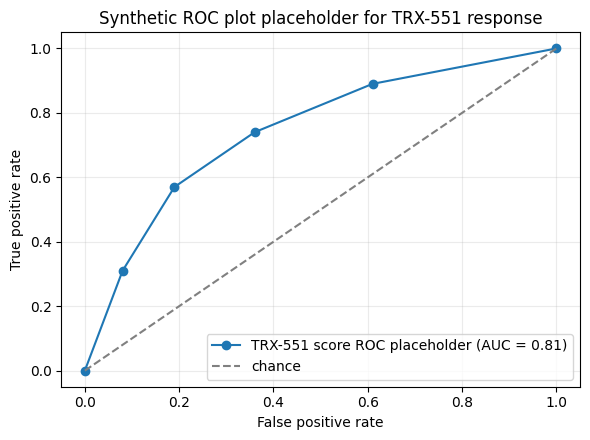

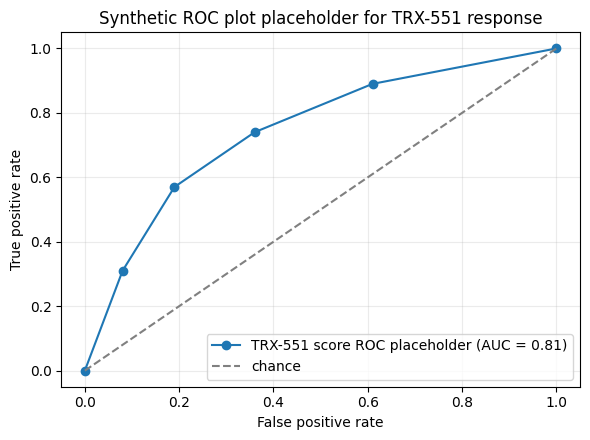

In [7]:
roc_curve_placeholder = pd.DataFrame({
    "false_positive_rate": [0.00, 0.08, 0.19, 0.36, 0.61, 1.00],
    "true_positive_rate": [0.00, 0.31, 0.57, 0.74, 0.89, 1.00],
})

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(
    roc_curve_placeholder["false_positive_rate"],
    roc_curve_placeholder["true_positive_rate"],
    marker="o",
    label="TRX-551 score ROC placeholder (AUC = 0.81)",
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="chance")
ax.set_title("Synthetic ROC plot placeholder for TRX-551 response")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.25)
plt.tight_layout()
fig

## Bioinformatics Conclusion

In this deterministic synthetic analysis, the integrated TRX-551 response score reports `roc_auc 0.81` and `average_precision 0.76`. The feature importance table identifies `top_predictive_feature IFNG_signature`, supporting the conclusion that `IFNG_signature` is the top predictive feature for therapy response in this synthetic multi-omics cohort.